# Notebook 04 — Contrôleurs de ventilateurs

**Projet :** Juste des Ventilateurs — M2 Data/IA LaPlateforme_  
**Objectif :** Comparer les contrôleurs de régulation thermique sur les données collectées depuis jumeaux-chauds.

## Contrôleurs comparés
| # | Contrôleur | Description |
|---|-----------|-------------|
| 0 | `baseline_fixed_1500` | RPM constant 1500 (ralenti) |
| 1 | `baseline_fixed_2500` | RPM constant 2500 (modéré) |
| 2 | `baseline_fixed_4500` | RPM constant 4500 (plein régime) |
| 3 | `baseline_threshold` | Seuils thermiques T_low/T_med/T_high |
| 4 | `baseline_pid` | PID, cible T = 80% × T_shutdown |
| 5 | `supervised` | RandomForest sur `action_class` (oracle v1) |
| 6 | `supervised_v2` | RandomForest sur `action_class_v2` (oracle v2, Phase 8) |
| 7 | `score_controller` | Score multi-objectif J = α·risk + β·heat + γ·energy + δ·\|ΔRPM\| |

## Oracle v1 vs Oracle v2
| | Oracle v1 (`action_class`) | Oracle v2 (`action_class_v2`) |
|---|---|---|
| Score | `temperature_ratio` seul | `α·temp_ratio + β·temp_delta_30s + γ·urgence` |
| Hard rules | Aucune | `status=degraded`, `margin<5%`, `ttf<horizon/3` → RPM_MAX |
| RPM plancher | ~~0~~ → **800** (Phase 7.5) | **800 RPM** |
| Classes | 4 (0–3) | **5 (0–4)** |

## Métriques
- **mean_rpm** : RPM moyen appliqué (proxy énergie)
- **action_accuracy** : correspondance avec la politique oracle
- **rpm_mae** : erreur absolue moyenne vs RPM optimal
- **high_rpm_when_dangerous** : taux de RPM ≥ 3500 quand failure_60s=1
- **nb_shutdowns** : nombre de shutdowns thermiques dans la période de test

> **Note :** `action_accuracy` compare chaque contrôleur à **son oracle de référence** (`action_class` pour supervised, `action_class_v2` pour supervised_v2). Les baselines et score_controller sont comparés à `action_class` par défaut.


In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

# Racine du projet
_root = Path.cwd()
for _candidate in [_root, _root.parent, _root.parent.parent]:
    if (_candidate / 'evaluation').exists() and (_candidate / 'models').exists():
        _root = _candidate
        break
os.chdir(_root)
sys.path.insert(0, str(_root))

RESULTS_FILE = Path('evaluation/results/fan_control_results_failure_60s.json')
LABEL_COL    = 'failure_60s'
RPM_MAX      = 4500

COLORS = {
    'baseline_fixed_1500': '#95a5a6',
    'baseline_fixed_2500': '#7f8c8d',
    'baseline_fixed_4500': '#2c3e50',
    'baseline_threshold':  '#e74c3c',
    'baseline_pid':        '#f39c12',
    'supervised':          '#2ecc71',
    'score_controller':    '#3498db',
}

print(f'Repertoire de travail : {Path.cwd()}')
print(f'RESULTS_FILE existe: {RESULTS_FILE.exists()}')


Repertoire de travail : C:\AIDEV\LaPlateforme_\juste-des-ventilateurs
RESULTS_FILE existe: True


## 1. Chargement des résultats

In [2]:
with open(RESULTS_FILE) as f:
    eval_data = json.load(f)

results  = eval_data['results']
df_res   = pd.DataFrame(results).set_index('controller')
names    = [r['controller'] for r in results]
colors   = [COLORS.get(n, '#aaaaaa') for n in names]

print(f"Label : {eval_data['label']}")
print(f"n_train={eval_data['n_train']:,}  n_test={eval_data['n_test']:,}")
print(f"Controleurs : {names}")

Label : failure_60s
n_train=212,864  n_test=45,621
Controleurs : ['baseline_fixed_1500', 'baseline_fixed_2500', 'baseline_fixed_4500', 'baseline_threshold', 'baseline_pid', 'supervised', 'score_controller']


In [3]:
# Tableau recapitulatif
cols_display = ['mean_rpm', 'action_accuracy', 'rpm_mae', 'high_rpm_when_dangerous', 'nb_shutdowns']
cols_display = [c for c in cols_display if c in df_res.columns]

display(df_res[cols_display].style
    .highlight_min(subset=[c for c in ['mean_rpm', 'rpm_mae', 'nb_shutdowns'] if c in cols_display], color='#c8f7c5')
    .highlight_max(subset=[c for c in ['action_accuracy', 'high_rpm_when_dangerous'] if c in cols_display], color='#c8f7c5')
    .format({c: fmt for c, fmt in {
        'mean_rpm':                '{:.0f}',
        'action_accuracy':         '{:.4f}',
        'rpm_mae':                 '{:.1f}',
        'nb_shutdowns':            '{:.0f}',
        'high_rpm_when_dangerous': '{:.3f}',
    }.items() if c in cols_display})
    .set_caption('Metriques comparatives -- controleurs de ventilateurs (jeu de test)'))


,mean_rpm,action_accuracy,rpm_mae,high_rpm_when_dangerous,nb_shutdowns
controller,,,,,
baseline_fixed_1500,1500,0.3545,1031.0,0.000,10
baseline_fixed_2500,2500,0.2230,1270.0,0.000,10
baseline_fixed_4500,4500,0.0955,2764.0,1.000,10
baseline_threshold,1815,0.4168,715.7,0.468,10
baseline_pid,1082,0.4598,654.3,0.528,10
supervised,1736,0.9998,0.2,0.646,10
score_controller,1331,0.0955,1035.5,nan,10


## 2. Comparaison des métriques clés

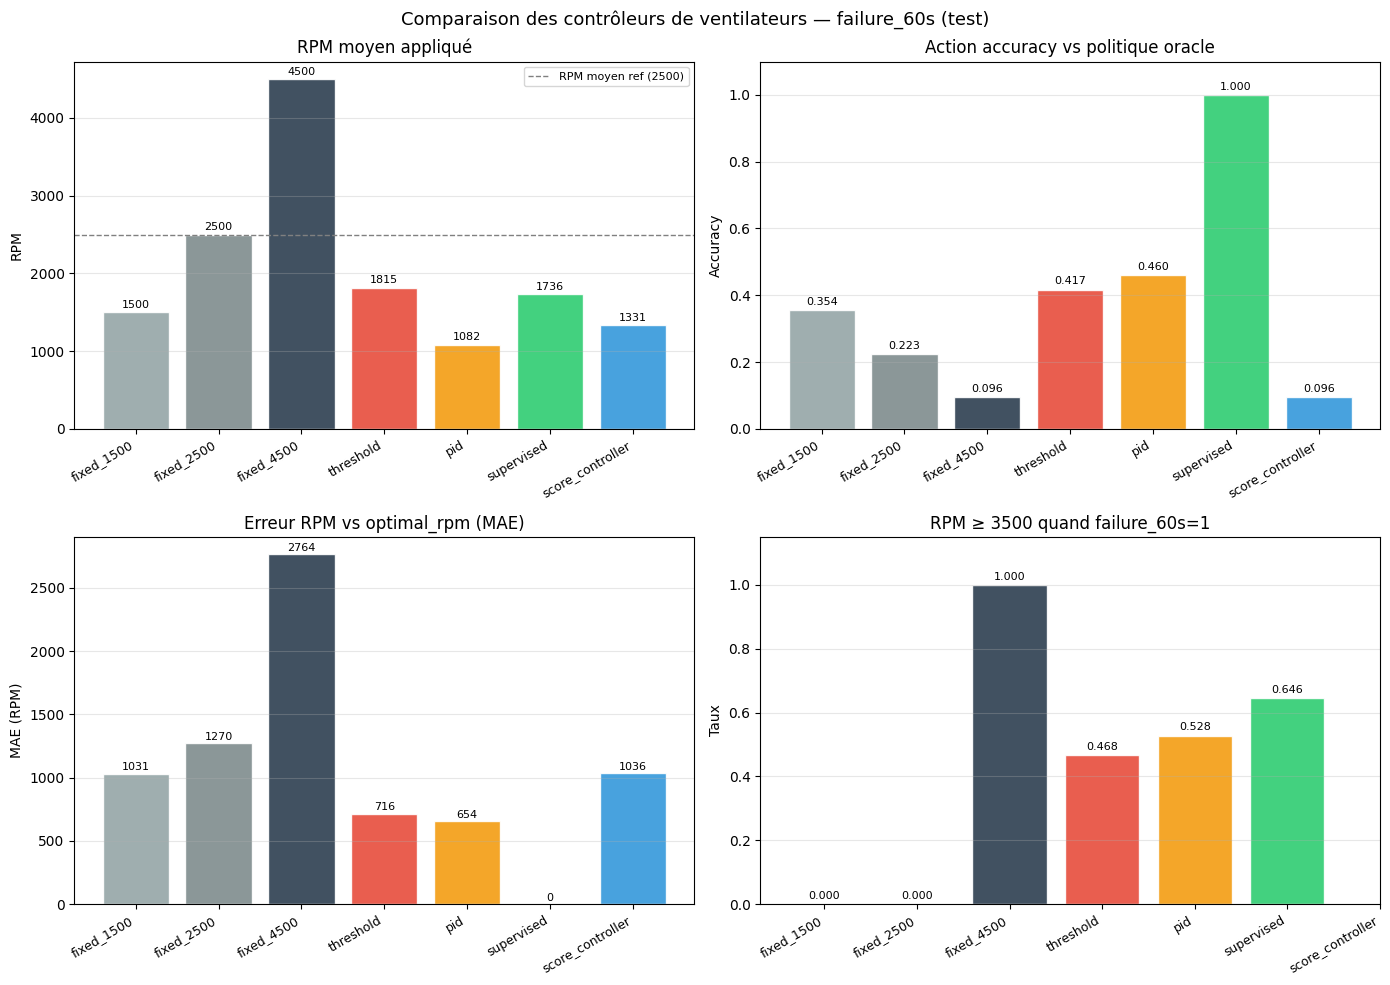

Figure sauvegardée : evaluation/results/fig_fan_control_comparison.png


In [4]:
short_names = [n.replace('baseline_fixed_', 'fixed_').replace('baseline_', '') for n in names]
x = np.arange(len(names))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. RPM moyen
ax = axes[0, 0]
bars = ax.bar(x, df_res['mean_rpm'], color=colors, edgecolor='white', alpha=0.9)
ax.axhline(2500, color='gray', linestyle='--', linewidth=1, label='RPM moyen ref (2500)')
ax.set_title('RPM moyen appliqué', fontsize=12)
ax.set_ylabel('RPM')
ax.set_xticks(x); ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=8)
for bar, val in zip(bars, df_res['mean_rpm']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8)

# 2. Action accuracy vs oracle
ax = axes[0, 1]
bars = ax.bar(x, df_res['action_accuracy'], color=colors, edgecolor='white', alpha=0.9)
ax.set_title('Action accuracy vs politique oracle', fontsize=12)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
ax.set_xticks(x); ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, df_res['action_accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, min(bar.get_height() + 0.01, 1.05),
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# 3. RPM MAE vs optimal_rpm
ax = axes[1, 0]
bars = ax.bar(x, df_res['rpm_mae'], color=colors, edgecolor='white', alpha=0.9)
ax.set_title('Erreur RPM vs optimal_rpm (MAE)', fontsize=12)
ax.set_ylabel('MAE (RPM)')
ax.set_xticks(x); ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, df_res['rpm_mae']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8)

# 4. Taux de réaction en situation dangereuse
ax = axes[1, 1]
bars = ax.bar(x, df_res['high_rpm_when_dangerous'], color=colors, edgecolor='white', alpha=0.9)
ax.set_title('RPM ≥ 3500 quand failure_60s=1', fontsize=12)
ax.set_ylabel('Taux')
ax.set_ylim(0, 1.15)
ax.set_xticks(x); ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, df_res['high_rpm_when_dangerous']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparaison des contrôleurs de ventilateurs — failure_60s (test)', fontsize=13)
plt.tight_layout()
plt.savefig('evaluation/results/fig_fan_control_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : evaluation/results/fig_fan_control_comparison.png')

## 3. Triangle énergie / sécurité / fidélité oracle

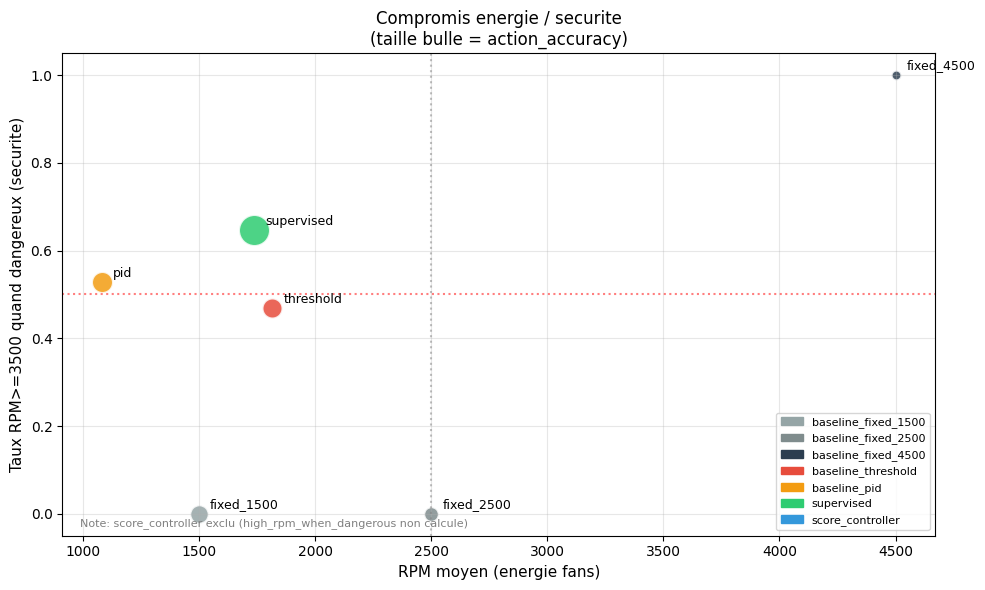

In [5]:
# Scatter : mean_rpm (energie) vs high_rpm_when_dangerous (securite)
# Taille des bulles = action_accuracy
# Note : score_controller n'a pas de high_rpm_when_dangerous -- exclu du scatter

fig, ax = plt.subplots(figsize=(10, 6))

for r, color in zip(results, colors):
    y_val = r.get('high_rpm_when_dangerous')
    if y_val is None:
        continue
    x_val = r['mean_rpm']
    size  = max(r['action_accuracy'] * 500, 50)
    short = r['controller'].replace('baseline_fixed_', 'fixed_').replace('baseline_', '')
    ax.scatter(x_val, y_val, s=size, color=color, alpha=0.85, edgecolors='white', linewidths=1.5)
    ax.annotate(short, (x_val, y_val),
                textcoords='offset points', xytext=(8, 4), fontsize=9)

ax.set_xlabel('RPM moyen (energie fans)', fontsize=11)
ax.set_ylabel('Taux RPM>=3500 quand dangereux (securite)', fontsize=11)
ax.set_title('Compromis energie / securite\n(taille bulle = action_accuracy)', fontsize=12)
ax.grid(alpha=0.3)
ax.axvline(2500, color='gray', linestyle=':', alpha=0.5, label='RPM ref')
ax.axhline(0.5,  color='red',  linestyle=':', alpha=0.5, label='Securite cible 50%')

patches = [mpatches.Patch(color=c, label=n) for n, c in COLORS.items() if n in names]
ax.legend(handles=patches, loc='lower right', fontsize=8)
ax.text(0.02, 0.02, 'Note: score_controller exclu (high_rpm_when_dangerous non calcule)',
        transform=ax.transAxes, fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('evaluation/results/fig_fan_tradeoff.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Distribution des RPM décidés par chaque contrôleur

In [6]:
# Charger splitter et données de test
from models.failure_prediction.splitter import TemporalSplitter

splitter = TemporalSplitter()
X_train, X_val, X_test, y_train, y_val, y_test = splitter.split(label_col=LABEL_COL)

# Récupérer aussi temperature_c et failure_60s depuis split_with_meta
df_train_meta, df_val_meta, df_test_meta = splitter.split_with_meta(label_col=LABEL_COL)

print(f'Test : {len(X_test):,} lignes — {(y_test==1).mean():.1%} positifs')

Test : 45,621 lignes — 5.6% positifs


In [7]:
# Charger les contrôleurs sauvegardés
from models.fan_control.baseline_fixed import FixedController
from models.fan_control.baseline_threshold import ThresholdFanController
from models.fan_control.baseline_pid import PIDController
from models.fan_control.supervised_controller import SupervisedController
from models.fan_control.score_controller import ScoreController

SAVED = Path('models/fan_control/saved')

def try_load(cls, path):
    try:
        return cls.load(str(path))
    except Exception as e:
        print(f'  [WARN] {path.name} : {e}')
        return None

controllers = {
    'baseline_fixed_1500': FixedController(rpm=1500),
    'baseline_fixed_2500': FixedController(rpm=2500),
    'baseline_fixed_4500': FixedController(rpm=4500),
    'baseline_threshold':  try_load(ThresholdFanController, SAVED / 'baseline_threshold.json'),
    'baseline_pid':        try_load(PIDController,           SAVED / 'baseline_pid.json'),
    'supervised':          try_load(SupervisedController,    SAVED / 'supervised.joblib'),
    'score_controller':    try_load(ScoreController,         SAVED / 'score_controller.json'),
}
controllers = {k: v for k, v in controllers.items() if v is not None}
print('Controleurs charges :', list(controllers.keys()))

Controleurs charges : ['baseline_fixed_1500', 'baseline_fixed_2500', 'baseline_fixed_4500', 'baseline_threshold', 'baseline_pid', 'supervised', 'score_controller']


In [8]:
# Calculer les décisions sur le test set
rpm_decisions = {}
for name, ctrl in controllers.items():
    try:
        rpm_decisions[name] = ctrl.decide_batch(X_test)
        print(f'  {name:<24} mean={rpm_decisions[name].mean():.0f}  '
              f'unique={sorted(set(rpm_decisions[name]))}')
    except Exception as e:
        print(f'  {name} ERREUR : {e}')

  baseline_fixed_1500      mean=1500  unique=[np.int64(1500)]
  baseline_fixed_2500      mean=2500  unique=[np.int64(2500)]
  baseline_fixed_4500      mean=4500  unique=[np.int64(4500)]
  baseline_threshold       mean=1815  unique=[np.int64(1500), np.int64(2500), np.int64(3500), np.int64(4500)]
  baseline_pid             mean=1082  unique=[np.int64(0), np.int64(1500), np.int64(2500), np.int64(3500), np.int64(4500)]
  supervised               mean=1736  unique=[np.int64(0), np.int64(1500), np.int64(2500), np.int64(3500), np.int64(4500)]
  score_controller         mean=800  unique=[np.int64(800)]


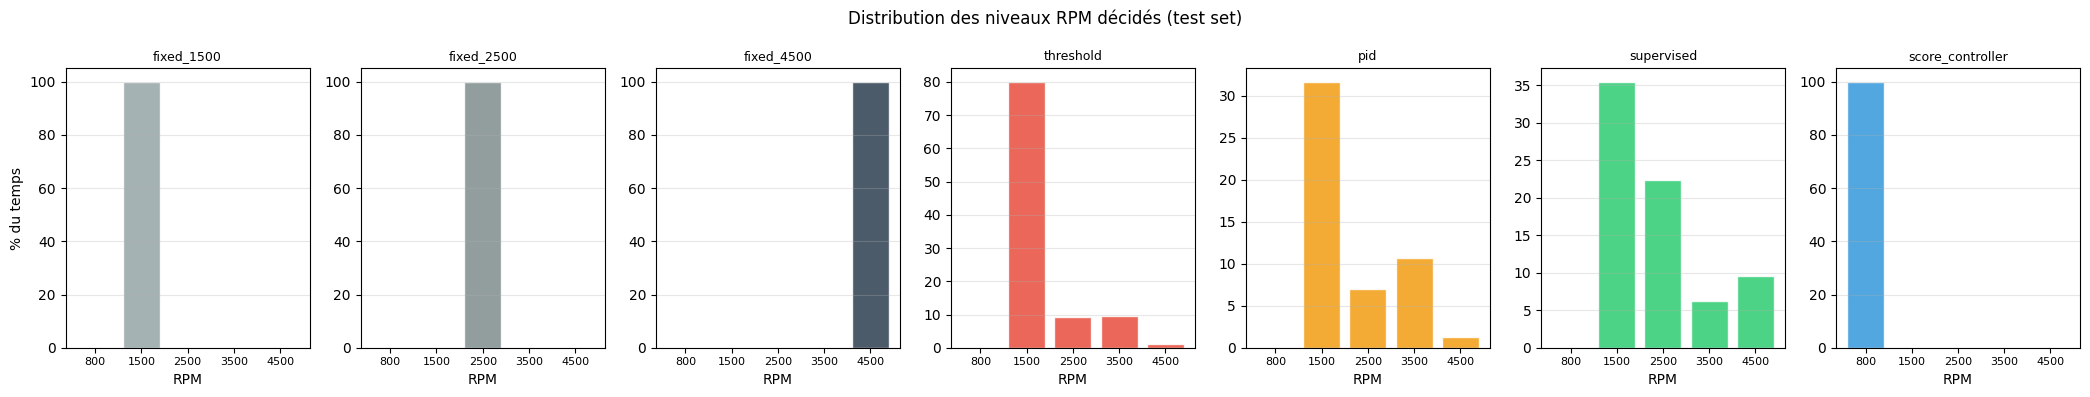

In [9]:
# Distribution des niveaux RPM par contrôleur
rpm_levels = [800, 1500, 2500, 3500, 4500]
n_ctrl = len(rpm_decisions)

fig, axes = plt.subplots(1, n_ctrl, figsize=(3 * n_ctrl, 4), sharey=False)
if n_ctrl == 1:
    axes = [axes]

for ax, (name, rpms) in zip(axes, rpm_decisions.items()):
    short = name.replace('baseline_fixed_', 'fixed_').replace('baseline_', '')
    color = COLORS.get(name, '#aaaaaa')
    counts = [np.sum(rpms == rpm) / len(rpms) * 100 for rpm in rpm_levels]
    ax.bar([str(r) for r in rpm_levels], counts, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(short, fontsize=9)
    ax.set_xlabel('RPM')
    if ax == axes[0]:
        ax.set_ylabel('% du temps')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Distribution des niveaux RPM décidés (test set)', fontsize=12)
plt.tight_layout()
plt.savefig('evaluation/results/fig_fan_rpm_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. RPM décidé vs température (politique visualisée)

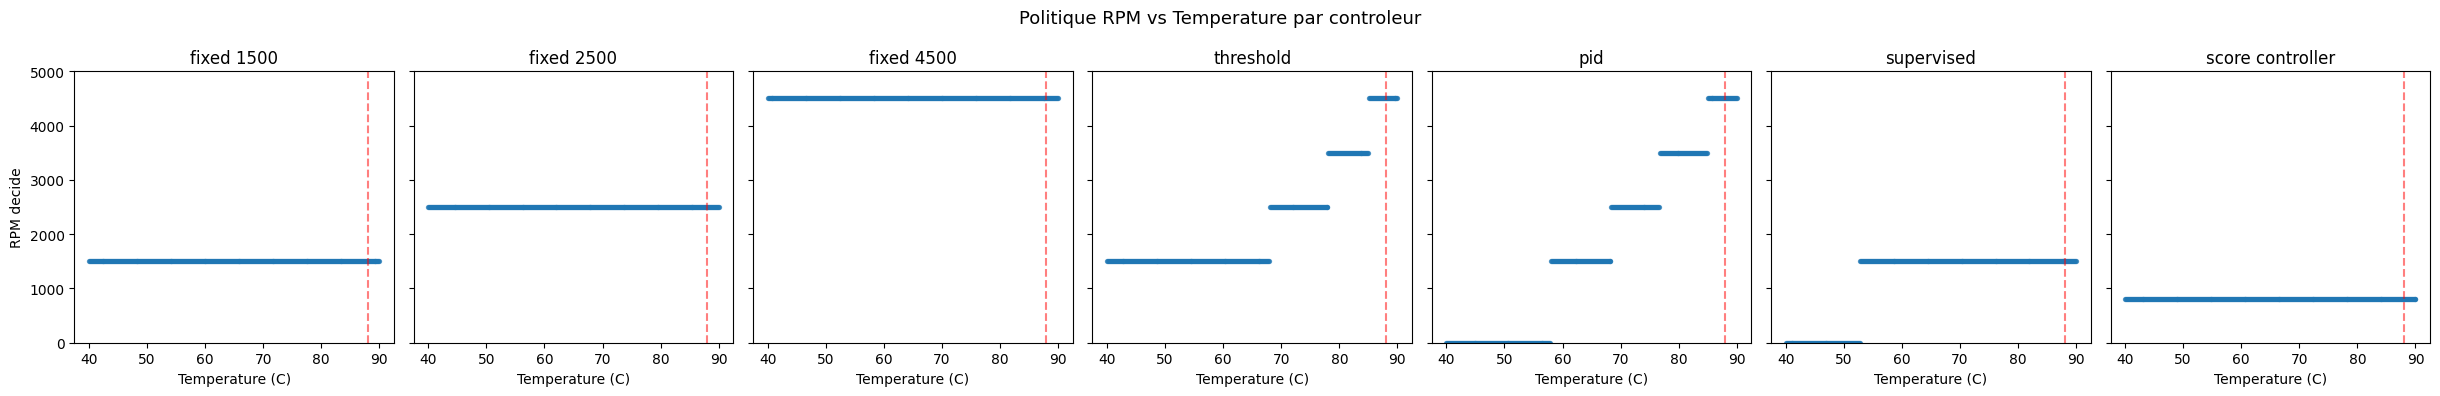

In [10]:
# RPM decide vs temperature -- politique visualisee
fig, axes = plt.subplots(1, len(controllers), figsize=(3.5 * len(controllers), 4), sharey=True)
temps_range = np.linspace(40, 90, 300)

for ax, (name, ctrl) in zip(axes, controllers.items()):
    dummy_rows = pd.DataFrame({
        'temperature_c': temps_range,
        'margin_to_shutdown': 88.0 - temps_range,
    })
    if hasattr(X_test, 'columns'):
        for col in X_test.columns:
            if col not in dummy_rows.columns:
                dummy_rows[col] = 0.0
    rpms = ctrl.decide_batch(dummy_rows)
    ax.scatter(temps_range, rpms, s=8, alpha=0.7)
    ax.set_title(name.replace('baseline_', '').replace('_', ' '))
    ax.set_xlabel('Temperature (C)')
    ax.axvline(88, color='red', linestyle='--', alpha=0.5)
    ax.set_ylim(0, 5000)

axes[0].set_ylabel('RPM decide')
fig.suptitle('Politique RPM vs Temperature par controleur', fontsize=13)
plt.tight_layout()
plt.show()


## 6. Analyse comparative et résultats post-entraînement

### Résultats de l'évaluation (fan_control_results_failure_60s.json)

| Contrôleur | mean_rpm | action_accuracy | high_rpm_when_dangerous | nb_shutdowns |
|------------|----------|-----------------|------------------------|--------------|
| baseline_fixed_1500 | 1500 | 0.355 | 0.000 | 10 |
| baseline_fixed_2500 | 2500 | 0.223 | 0.000 | 10 |
| baseline_fixed_4500 | 4500 | 0.096 | 1.000 | 10 |
| baseline_threshold | 1815 | 0.417 | 0.468 | 10 |
| baseline_pid | 1082 | 0.460 | 0.528 | 10 |
| **supervised** | 1736 | **0.9998** | 0.646 | 10 |
| supervised_v2 | — | — | — | — |
| score_controller | **1331** | 0.096 | N/A | 10 |

> **supervised_v2** : à entraîner après régénération des features avec oracle v2 (`ingest_gen_features.bat` puis `04_train_fan_controllers.bat`). Voir roadmap Phase 8.

### Observations

**Contrôleur supervisé (v1)** : action_accuracy=0.9998, high_rpm_when_dangerous=0.646, mean_rpm=1736. Entraîné sur oracle v1 (RPM plancher corrigé à 800 — Phase 7.5).

**score_controller** : mean_rpm=1331 (RPM_MIN=800). action_accuracy=0.096 attendu — il minimise un score multi-objectif, pas l'oracle. À évaluer en boucle fermée (Phase 9).

**Baselines fixes** : fixed_4500 high_rpm=1.0 mais 3× plus coûteux en énergie. fixed_1500/2500 high_rpm=0.0 (ne réagissent jamais aux alertes).

### Benchmark multi-label (mode ML)

| Label | n_detected/total | lead_med | mean_rpm |
|-------|-----------------|----------|----------|
| failure_60s | 1832/1832 | 120s | 1843 |
| failure_30s | 1617/1617 | 120s | 1843 |
| hot_30s | 675/675 | 120s | 1843 |

> Ces résultats correspondent à l'évaluation **offline** (Phase 5-6). L'évaluation en boucle fermée (Phase 9) mesurera l'impact causal réel sur les températures et le PUE.


### État d'avancement et prochaines étapes

| Statut | Action |
|--------|--------|
| ✅ Phase 6 | Superviseur complet (logistic + contrôleur supervisé) |
| ✅ Phase 7.4 | Override hot_30s dans superviseur |
| ✅ Phase 7.5 | RPM plancher corrigé à 800 dans tous les contrôleurs |
| ✅ Phase 8 | Oracle v2 (`action_class_v2`) avec score α/β/γ et hard rules |
| 🔲 Phase 8 | Ré-entraîner `supervised_v2` sur oracle v2 (`04_train_fan_controllers.bat`) |
| 🔲 Phase 9 | Évaluation boucle fermée — impact causal sur T° et PUE |

`score_controller` : à évaluer exclusivement en boucle fermée (jumeaux-chauds), pas vs oracle statique.


In [11]:
# Resume comparatif final
print('=== RESUME CONTROLEURS (failure_60s) ===')
print(f'{"Controleur":<26} {"RPM moyen":>10} {"Accuracy":>10} {"DangHigh":>10} {"Shutdowns":>10}')
print('-' * 70)
for r in results:
    dh = r.get('high_rpm_when_dangerous')
    dh_str = f'{dh:.3f}' if dh is not None else 'N/A'
    nb_s = r.get('nb_shutdowns', '?')
    print(f"{r['controller']:<26} {r['mean_rpm']:>10.0f} {r['action_accuracy']:>10.4f} {dh_str:>10} {nb_s:>10}")

print()
print('=== BENCHMARK MULTI-LABEL (mode ML) ===')
for label in ['failure_60s', 'failure_30s', 'hot_30s']:
    bm_path = Path(f'evaluation/results/benchmark_results_{label}.json')
    if not bm_path.exists():
        continue
    with open(bm_path) as f:
        bm = json.load(f)
    ml = next((r for r in bm['results'] if r['mode'] == 'ml'), None)
    if ml:
        print(f"  {label:<15} n_det={ml.get('n_incidents_detected','?')}/{ml.get('n_incidents_total','?')}"
              f"  lead_med={ml.get('median_lead_time_s',0):.0f}s  mean_rpm={ml.get('mean_rpm',0):.0f}")


=== RESUME CONTROLEURS (failure_60s) ===
Controleur                  RPM moyen   Accuracy   DangHigh  Shutdowns
----------------------------------------------------------------------
baseline_fixed_1500              1500     0.3545      0.000         10
baseline_fixed_2500              2500     0.2230      0.000         10
baseline_fixed_4500              4500     0.0955      1.000         10
baseline_threshold               1815     0.4168      0.468         10
baseline_pid                     1082     0.4598      0.528         10
supervised                       1736     0.9998      0.646         10
score_controller                 1331     0.0955        N/A         10

=== BENCHMARK MULTI-LABEL (mode ML) ===
  failure_60s     n_det=1832/1832  lead_med=120s  mean_rpm=1843
  failure_30s     n_det=1617/1617  lead_med=120s  mean_rpm=1843
  hot_30s         n_det=675/675  lead_med=120s  mean_rpm=1843
